In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def chiarella(T=600, alpha=1/7, kappa=0.015, beta=0.015, gamma=36.7,
                           sigma_N=0.04, sigma_V=0.018, g=0.0011, v0=4.42, kappa3=0.02):
    
    # T : durée dimulation ; alpha : paramètre de lissage pour le signal de tendance ; kappa : poids des fondamentalistes ; beta : poids des suiveurs de tendances
    # gamma : paramètre de saturation de la demande des suiveurs de tendance ; sigma_N : volatilité apporté par le bruit ; sigma_V : volatilité de la valeur fondamentale 
    # g : dérive = croissance moyenne ; v0 : log-valeur fondamentale initiale ; kappa3 : coeff de la demande cubique des fondamentalistes
   
   
    # condition de stabilité définie par l'article : alpha + kappa - alpha*gamma*beta >= 0 
    
    
    
    p = np.zeros(T)
    v = np.zeros(T)
    m = np.zeros(T)
    
    # Initialisation
    v[0] = v0
    p[0] = v0
    m[0] = 0.0
    
    for t in range(T-1):
        # 1. Évolution de la valeur fondamentale (marche aléatoire avec dérive) 
        v[t+1] = v[t] + g + np.random.normal(0, sigma_V)
        
        # 2. Signal de tendance (moyenne mobile exponentielle des rendements) 
        dp_prev = p[t] - p[t-1] if t > 0 else 0
        m[t+1] = (1 - alpha) * m[t] + alpha * dp_prev
        
        # 3. Calcul des demandes des agents 
        # Demande fondamentaliste (linéaire + option cubique) 
        mispricing = v[t+1] - p[t]
        demand_fund = kappa * mispricing + kappa3 * (mispricing**3)
        
        # Demande des suiveurs de tendance (non-linéaire avec saturation) 
        demand_trend = beta * np.tanh(gamma * m[t+1])
        
        # 4. Mise à jour du prix avec bruit 
        p[t+1] = p[t] + demand_fund + demand_trend + np.random.normal(0, sigma_N)
        
    return p, v, m


<Figure size 1200x500 with 0 Axes>

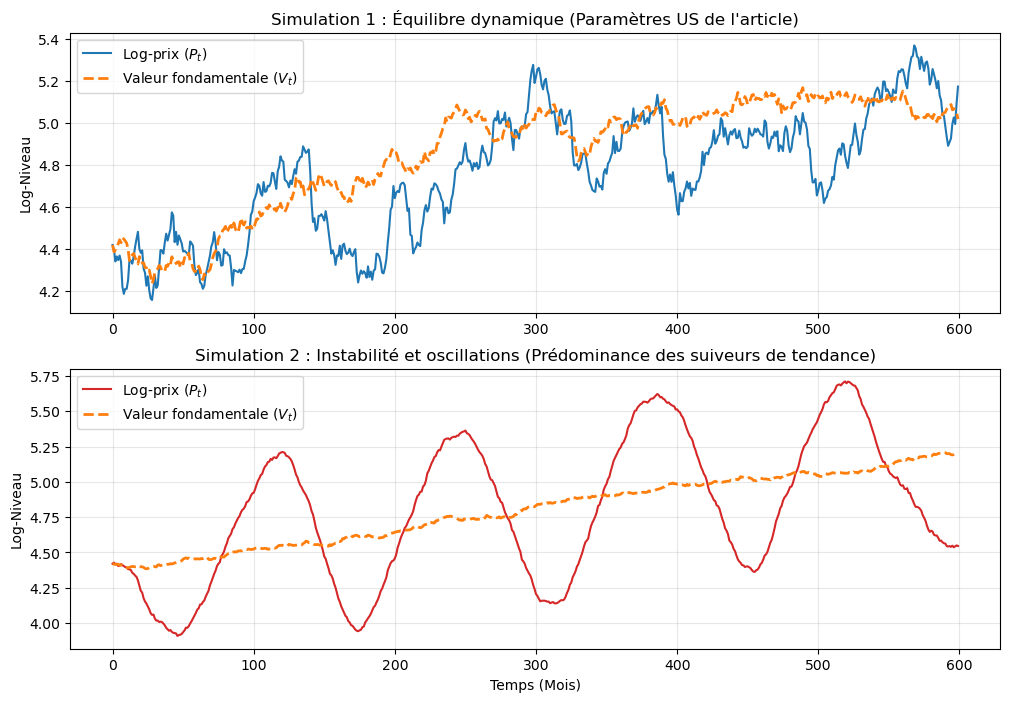

<Figure size 1200x500 with 0 Axes>

In [3]:
# Simulation 1 : Régime stable
p1, v1, m1 = chiarella()

# Simulation 2 : Régime instable 
p2, v2, m2 = chiarella(kappa=0.01, beta=0.03, gamma=50.0, sigma_N=0.01, sigma_V=0.005)

# Affichage des graphiques
plt.figure(figsize=(12, 8))

# Sous-graphique 1 : stabilité
plt.subplot(2, 1, 1)
plt.plot(p1, label='Log-prix ($P_t$)', color='#1f77b4', lw=1.5)
plt.plot(v1, label='Valeur fondamentale ($V_t$)', color='#ff7f0e', linestyle='--', lw=2)
plt.title("Simulation 1 : Équilibre dynamique (Paramètres US de l'article)")
plt.ylabel("Log-Niveau")
plt.legend()
plt.grid(True, alpha=0.3)

# Sous-graphique 2 : instabilité 
plt.subplot(2, 1, 2)
plt.plot(p2, label='Log-prix ($P_t$)', color='#d62728', lw=1.5)
plt.plot(v2, label='Valeur fondamentale ($V_t$)', color='#ff7f0e', linestyle='--', lw=2)
plt.title("Simulation 2 : Instabilité et oscillations (Prédominance des suiveurs de tendance)")
plt.xlabel("Temps (Mois)")
plt.ylabel("Log-Niveau")
plt.legend()
plt.grid(True, alpha=0.3)




plt.figure(figsize=(12, 5))

Text(0.5, 0, 'Distorsion (prix - valeur)')

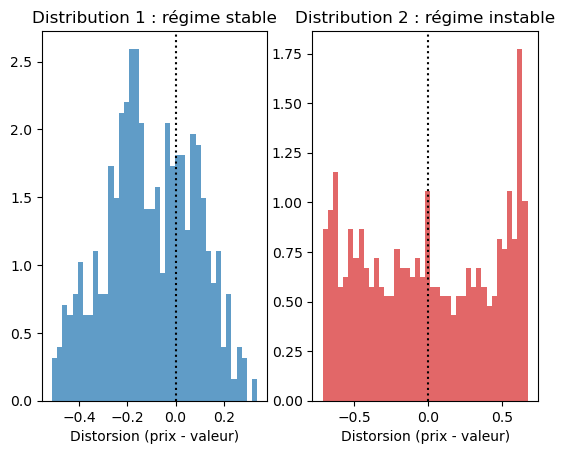

In [4]:
# Histogramme simulation 1 (régime stable / unimodal)
plt.subplot(1, 2, 1)
plt.hist(p1 - v1, bins=40, color="#1D73B0", alpha=0.7, density=True)
plt.axvline(0, color='black', linestyle=':')
plt.title("Distribution 1 : régime stable")
plt.xlabel("Distorsion (prix - valeur)")

# Histogramme simulation 2 (régime instable / bimodal)
plt.subplot(1, 2, 2)
plt.hist(p2 - v2, bins=40, color='#d62728', alpha=0.7, density=True)
plt.axvline(0, color='black', linestyle=':')
plt.title("Distribution 2 : régime instable")
plt.xlabel("Distorsion (prix - valeur)")